In [1]:
import pandas as pd
import numpy as np
import os
import torch
from tqdm import tqdm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
import os
os.chdir('..')
os.getcwd()

'/home/ubuntu/work/saved_data/tree_height_uncertainty_quantification'

## Get Validation Loader

Data is loaded from **dataset_path**.

In [6]:
data_path = '/home/ubuntu/work/satellite_data/datasets/canopy_height_prediction'
dataset_name = 'ai4forest_random_s1_s2_12_12_256_256'
dataset_path = os.path.join(data_path, dataset_name)

In [8]:
from datasetClass_file import SatelliteImageDataset

shift_year = 0
collapse_months = False
single_month_scaling = True
scale_adjustments = {
            'scale_adjust_1234': -0.1,
            'scale_adjust_6789': 0.0,
            'scale_adjust_0': 0.0,
            'scale_adjust_51011': 0.0,
        }
is_3d_model = True
time_mode = None
has_sentinel_1 = True


trainData_all = SatelliteImageDataset(data_path=dataset_path,
                                         shift_year=shift_year,
                                         collapse_months=collapse_months,
                                         single_month_scaling=single_month_scaling,
                                         scale_adjustments=scale_adjustments,
                                         is_3d_model=is_3d_model,
                                         time_mode=time_mode,
                                         has_sentinel_1=has_sentinel_1)

n_val = 1200
n_train = len(trainData_all) - n_val
trainData, valData = torch.utils.data.random_split(trainData_all, [n_train, n_val], generator=torch.Generator().manual_seed(1234))

batch_size = 1
prefetch_factor = 2 

valLoader = torch.utils.data.DataLoader(valData, batch_size=batch_size, shuffle=False,
                                        pin_memory=torch.cuda.is_available(), num_workers=2, prefetch_factor=prefetch_factor)

Single month scaling: True.
Collapse months: False.
Is 3D model: True.
Time mode: None.
Adjusted scaling dict: {(1, 2, 3, 4): (0, 1800.0), (6, 7, 8, 9): (0, 6000.0), (0,): (0, 1000.0), (5, 10, 11): (0, 4000.0)}.


## Load model

The model is loaded from a **model_path**.

In [9]:
model_name = 'leafy-sweep-2'
model_path = os.path.join('pretrained_models/', model_name + '.pt')

In [10]:
quantiles = [0.5, 0.05, 0.1, 0.15,0.2,0.25,0.75, 0.8,0.85,0.9,0.95]
out_channels = len(quantiles)
from models.unet_3d_single_year import UNetTwelveMonth as SingleYearUNetTwelveMonth
n_bands = 16 
month  = 12
model = SingleYearUNetTwelveMonth(n_channels=n_bands, out_channels=out_channels)
model.to(device);
strict = True
model.load_state_dict(torch.load(model_path, map_location=device), strict=strict);

/tmp/ipykernel_1424361/3340087624.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device), strict=strict);


## Plot examples

The data from Lang et. al. was downloaded and saved in a directory **lang_path_dir**.

In [11]:
lang_path_dir = '/home/ubuntu/work/satellite_data/ai4forest/lang_download_val_cut'

In [12]:
lang_pred_dict = {}
lang_std_dict = {}
our_pred_dict = {}
input_dict = {}
rgb_channels = [3,2,1]


In [14]:
# file_name = 'T29SQD_2020_69.npz'
# file_name = 'T33UYQ_2020_128.npz'
# file_name = 'T29TNG_2020_14.npz'
# file_name = 'T31TDL_2020_25.npz'
files_wanted = ['T31TDL_2020_25.npz']
for file_name in files_wanted:
    lang_output = np.load(os.path.join(lang_path_dir, file_name), allow_pickle=True)['data']
    lang_pred_dict[file_name] = lang_output[1]
    lang_std_dict[file_name] = lang_output[0]
    for batch in tqdm(valLoader):
        images, labels, ids, current_file_name = batch
        current_file_name = str(current_file_name[0])
        current_file_name = current_file_name.split('/')[-1][:-1]
        model.eval()
        if current_file_name == file_name:
            images = images.to(device)
            output = model(images.to(device))
            output = output.to('cpu')
            our_pred_dict[file_name] = output[0].detach().numpy()
            input_dict[file_name] = np.median(images[0, rgb_channels].cpu().detach().numpy(), axis = 1)
            break
        else:
            continue

  5%|▌         | 63/1200 [00:07<02:07,  8.90it/s]


<Figure size 1500x600 with 0 Axes>

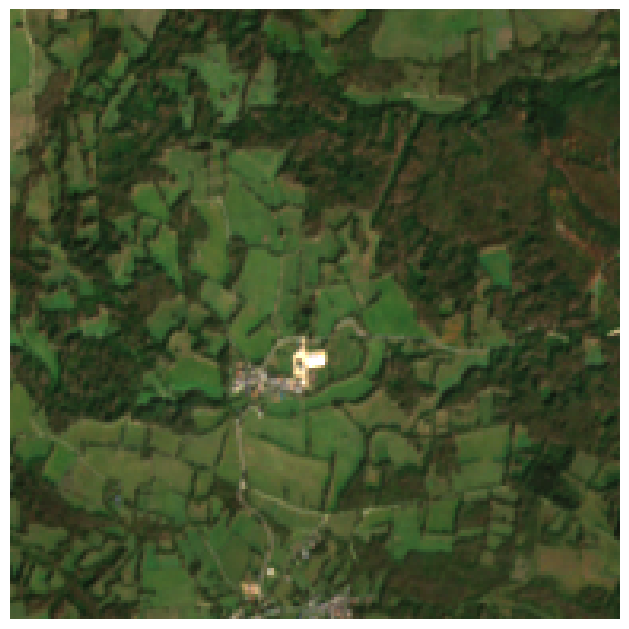

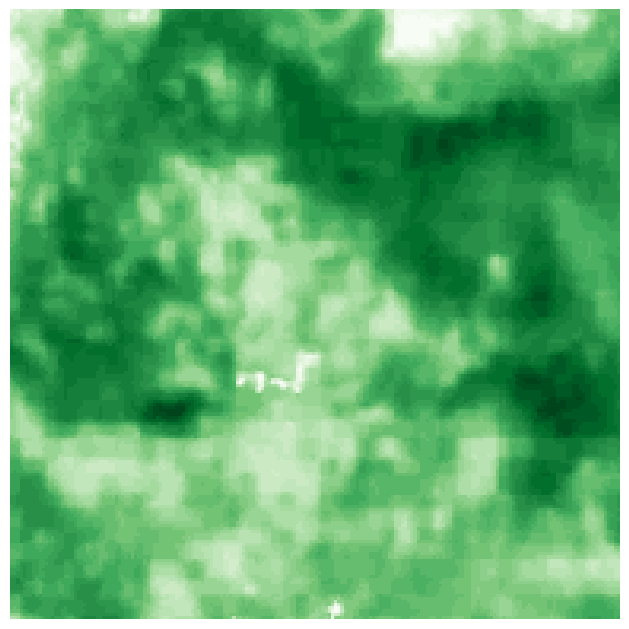

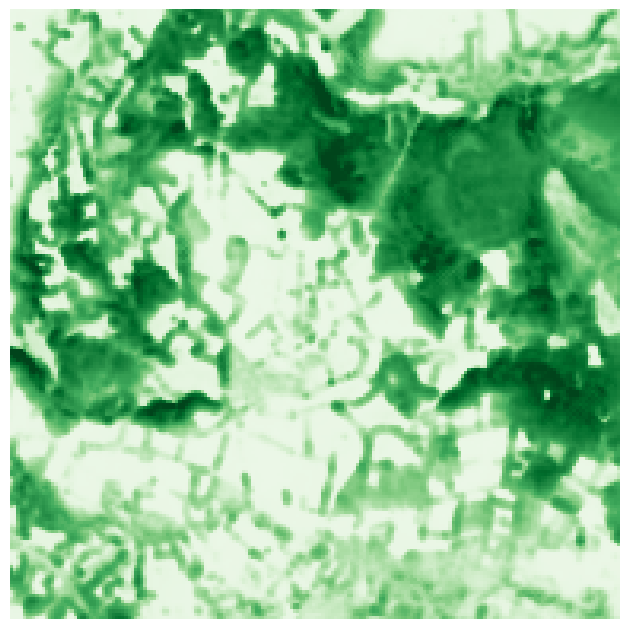

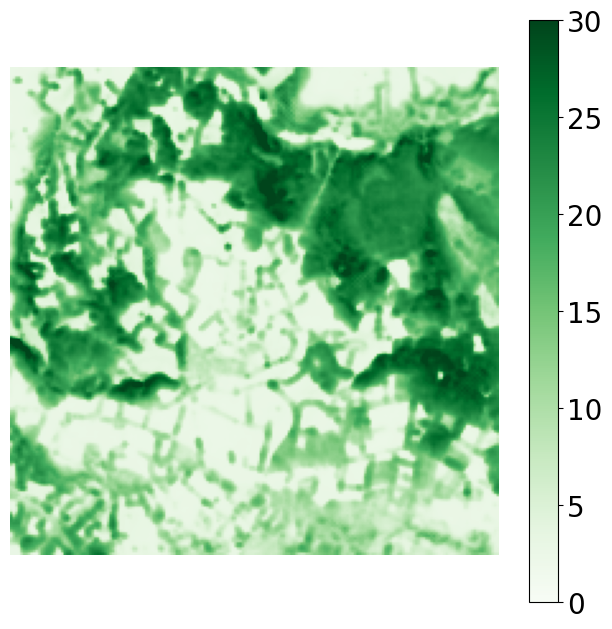

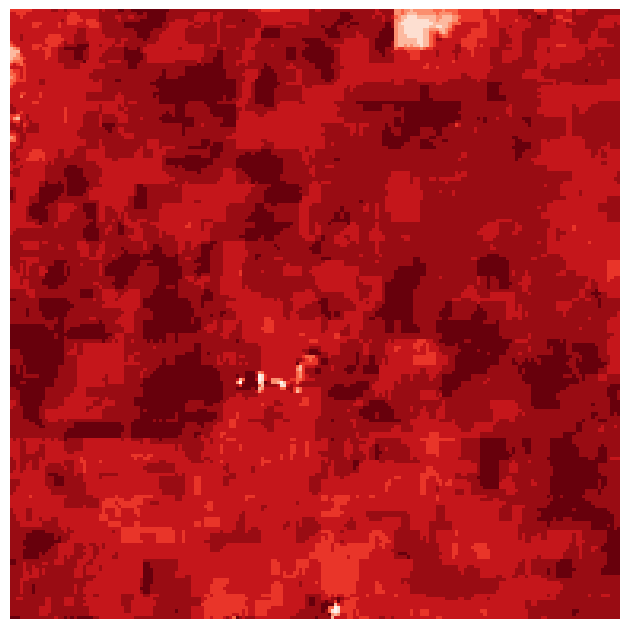

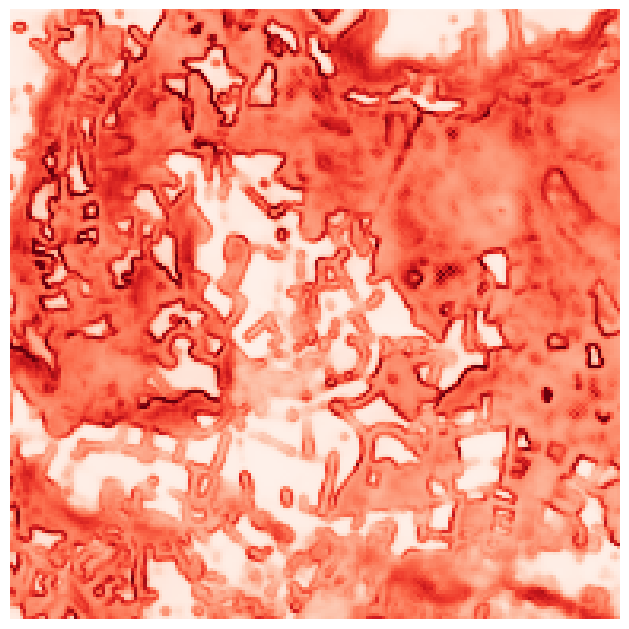

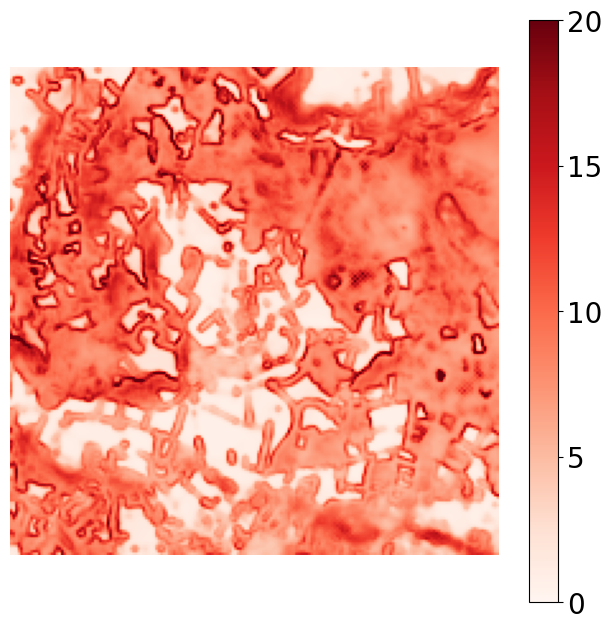

In [15]:
import matplotlib.pyplot as plt
from scipy.stats import norm
z_score = norm.ppf(0.9)
border_cutoff = 5
image_size = 192
start_rows = [5, 5]
start_cols = [5, 5]
pixel_window = 10
file_name = list(our_pred_dict.keys())[-1]
plt.figure(figsize=(15,6))

input_image = input_dict[file_name]
lang_pred = lang_pred_dict[file_name]
lang_std = lang_std_dict[file_name]
our_pred = our_pred_dict[file_name]
pred = our_pred[0]
upper_pred = our_pred[-2]
lower_pred = our_pred[2]
interval_width = upper_pred - lower_pred
lang_upper = lang_pred + z_score * lang_std
lang_lower = lang_pred - z_score * lang_std
lang_interval_width = lang_upper - lang_lower
start_row = start_rows[0]
start_col = start_cols[0]

plt.figure(figsize = (6.4,6.4))
plt.imshow(input_image.transpose(1,2,0)[start_row:start_row + image_size,start_col:start_col + image_size,:])
plt.axis('off')
plt.tight_layout()
# plt.savefig('results/qualitative_input_image3.png', bbox_inches='tight', dpi=300)

plt.figure(figsize=(6.4,6.4))
plt.imshow(lang_pred[start_row:start_row + image_size,start_col:start_col + image_size], vmin=0, vmax=30, cmap = 'Greens')
plt.axis('off')
plt.tight_layout()
# plt.savefig('results/qualitative_lang_pred3.png', bbox_inches='tight', dpi=300)

plt.figure(figsize=(6.4,6.4))
plt.imshow(pred[start_row:start_row + image_size,start_col:start_col + image_size], vmin=0, vmax=30, cmap = 'Greens')
plt.axis('off')
plt.tight_layout()
# plt.savefig('results/qualitative_our_wo_shift_pred3.png', bbox_inches='tight', dpi=300)

plt.figure(figsize=(6.4,6.4))
plt.imshow(pred[start_row:start_row + image_size,start_col:start_col + image_size], vmin=0, vmax=30, cmap = 'Greens')
plt.axis('off')
cbar = plt.colorbar(ticks=[0, 5, 10, 15, 20,25,30])
cbar.ax.tick_params(labelsize=20)
plt.tight_layout()
# plt.savefig('results/qualitative_our_pred_colorbar3.png', bbox_inches='tight', dpi=300)

plt.figure(figsize=(6.4,6.4))
plt.imshow(lang_interval_width[start_row:start_row + image_size,start_col:start_col + image_size], vmin=0, vmax=20, cmap = 'Reds')
plt.axis('off')
plt.tight_layout()
# plt.savefig('results/qualitative_lang_interval_width3.png', bbox_inches='tight', dpi=300)

plt.figure(figsize=(6.4,6.4))
plt.imshow(interval_width[start_row:start_row + image_size,start_col:start_col + image_size], vmin=0, vmax=20, cmap = 'Reds')
plt.axis('off')
plt.tight_layout()
# plt.savefig('results/qualitative_interval_width3_wo_shift.png', bbox_inches='tight', dpi=300)

plt.figure(figsize=(6.4,6.4))
plt.imshow(interval_width[start_row:start_row + image_size,start_col:start_col + image_size], vmin=0, vmax=20, cmap = 'Reds')
plt.axis('off')
cbar = plt.colorbar(ticks=[0, 5, 10, 15, 20])
cbar.ax.tick_params(labelsize=20)
plt.tight_layout()
# plt.savefig('results/qualitative_interval_width_colorbar3.png', bbox_inches='tight', dpi=300)

plt.tight_layout()